In [89]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,precision_score, recall_score, f1_score,confusion_matrix
import string


In [59]:
df=pd.read_csv('/content/email_spam.csv',encoding='latin-1')

In [60]:
df = df[['v1', 'v2']]

In [ ]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [61]:
df.columns = ['label', 'text']

In [62]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [63]:
df = df.dropna(subset=['text'])

In [64]:
df['text'] = df['text'].astype(str)

In [65]:
df = df[df['text'].str.strip() != ""]


In [66]:
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))

    return text

In [67]:
df['text'] = df['text'].apply(clean_text)

In [ ]:
df['text']

,text
0,go until jurong point crazy available only in ...
1,ok lar joking wif u oni
2,free entry in 2 a wkly comp to win fa cup fina...
3,u dun say so early hor u c already then say
4,nah i dont think he goes to usf he lives aroun...
...,...
5567,this is the 2nd time we have tried 2 contact u...
5568,will ì b going to esplanade fr home
5569,pity was in mood for that soany other suggest...
5570,the guy did some bitching but i acted like id ...


In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(3,3),
    max_df=0.9,
    min_df=5,
    sublinear_tf=True
)

In [69]:
X = tfidf.fit_transform(df['text'])
y = df['label']


In [70]:
print("Feature shape:", X.shape)

Feature shape: (5572, 3000)


In [71]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Logistic Regression

In [95]:
model=LogisticRegression(max_iter=1500,class_weight="balanced")
model.fit(X_train,y_train)
y_p=model.predict(X_test)

### model evlaution

In [96]:

cm = confusion_matrix(y_test, y_p)
print(cm)
print(accuracy_score(y_test,y_p))
print("Precision:", precision_score(y_test, y_p))
print("Recall:", recall_score(y_test, y_p))
print("F1 Score:", f1_score(y_test, y_p))

[[953  12]
 [ 16 134]]
0.9748878923766816
Precision: 0.9178082191780822
Recall: 0.8933333333333333
F1 Score: 0.9054054054054054


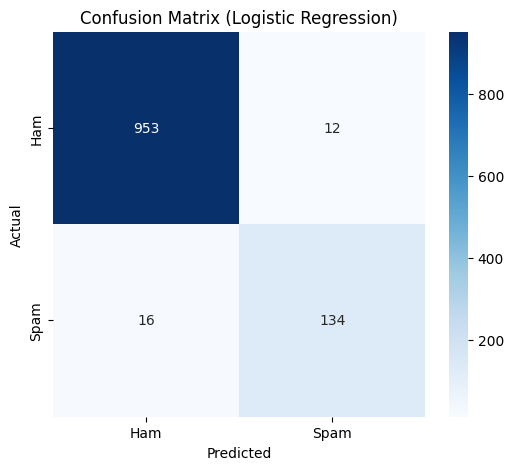

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
#  LR predictions
m = confusion_matrix(y_test, y_p)  # y_pred from SVM
plt.figure(figsize=(6,5))
sns.heatmap(m, annot=True, fmt="d", cmap="Blues", xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()

## SVM

In [84]:
from sklearn.svm import LinearSVC

model = LinearSVC(class_weight='balanced')
model.fit(X_train, y_train)
y_p=model.predict(X_test)
print(accuracy_score(y_test,y_p))

0.9811659192825112


In [85]:
m = confusion_matrix(y_test, y_p)
print(m)
print("Precision:", precision_score(y_test, y_p))
print("Recall:", recall_score(y_test, y_p))
print("F1 Score:", f1_score(y_test, y_p))

[[957   8]
 [ 13 137]]
Precision: 0.9448275862068966
Recall: 0.9133333333333333
F1 Score: 0.9288135593220339


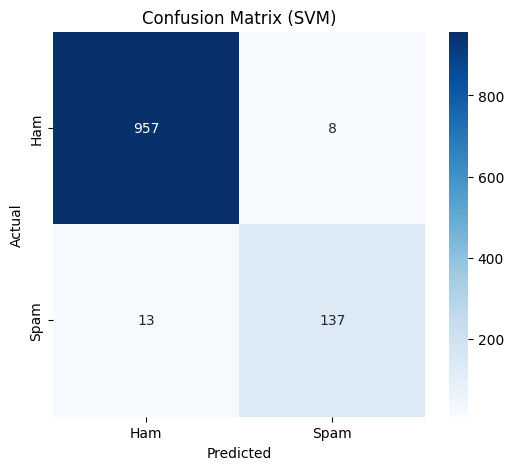

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
#  SVM predictions
m = confusion_matrix(y_test, y_p)  # y_pred from SVM
plt.figure(figsize=(6,5))
sns.heatmap(m, annot=True, fmt="d", cmap="Blues", xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SVM)")
plt.show()

In [80]:
from sklearn.naive_bayes import MultinomialNB

In [81]:
model = MultinomialNB(alpha=1.0, force_alpha=True, fit_prior=True, class_prior=None)
model.fit(X_train, y_train)
y_p=model.predict(X_test)

In [100]:
nv = confusion_matrix(y_test, y_p)
print(nv)
print("Precision:", precision_score(y_test, y_p))
print("Recall:", recall_score(y_test, y_p))
print("F1 Score:", f1_score(y_test, y_p))

[[953  12]
 [ 16 134]]
Precision: 0.9178082191780822
Recall: 0.8933333333333333
F1 Score: 0.9054054054054054


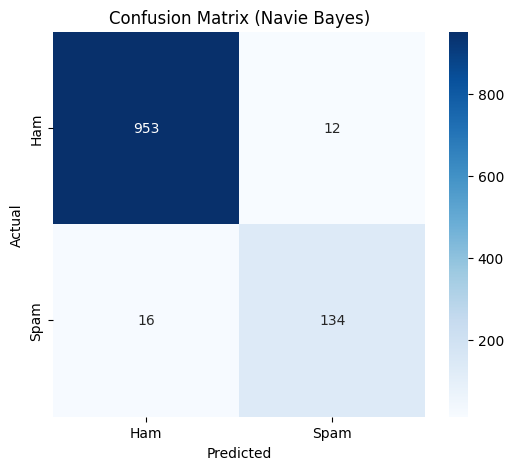

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
#  Navie Bayes predictions
nv = confusion_matrix(y_test, y_p)  # y_pred from SVM
plt.figure(figsize=(6,5))
sns.heatmap(nv, annot=True, fmt="d", cmap="Blues", xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Navie Bayes)")
plt.show()

# Comparison Plot

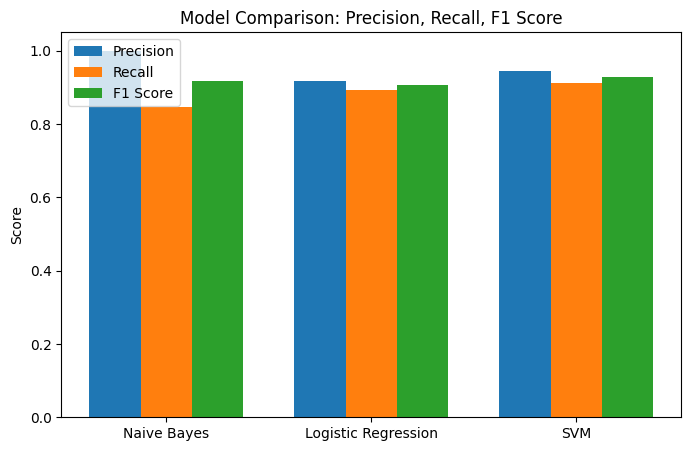

In [102]:
import numpy as np

models = ['Naive Bayes', 'Logistic Regression', 'SVM']
precision = [1.0, 0.918, 0.945]
recall = [0.846, 0.893, 0.913]
f1 = [0.917, 0.905, 0.929]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1 Score')

plt.xticks(x, models)
plt.ylabel('Score')
plt.ylim(0,1.05)
plt.title('Model Comparison: Precision, Recall, F1 Score')
plt.legend()
plt.show()